In [1]:
# ══════════════════════════════════════════════════════════════════════════
# Cell 1 — Setup
# ══════════════════════════════════════════════════════════════════════════
import os, sys, json, pickle, subprocess, time
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = os.path.expanduser("~/projects/iride_onboard-burnscar-mapper")
TRAINING_DIR = os.path.join(PROJECT_ROOT, "training")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, TRAINING_DIR)
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pyqnas", "src"))

from pynas.core.config import load_default_config
from pynas.core.population import Population

SAVE_DIR   = "models_traced"
TILES_ROOT = "processed/dataset_v1"
INDEX_CSV  = f"{TILES_ROOT}/tiles_index.csv"
NAMES      = ["clear","fresh_burn","old_burn","cloud","shadow","water"]

config = load_default_config()
print("Setup complete")

Setup complete


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# Cell 2 — Confirm winning architecture (sanity check before committing hours)
# ══════════════════════════════════════════════════════════════════════════
WINNER_GEN, WINNER_IDX, WINNER_PARAMS = 2, 29, 4_897_262

def _shape_signature(sd):
    return tuple(sorted((k, tuple(v.shape)) for k, v in sd.items()))

class LightDM: input_shape=(7,256,256); num_classes=6
pop = Population(n_individuals=30, max_layers=7, dm=LightDM(),
                 max_parameters=5_000_000, min_parameters=200_000, save_directory=SAVE_DIR)
pop.cfg = config

pkl = f"{SAVE_DIR}/src/population_{WINNER_GEN}.pkl"
if not os.path.exists(pkl): pkl = f"{SAVE_DIR}/src/population_0.pkl"
plist = pickle.load(open(pkl, "rb"))
matches = [ind for ind in plist if getattr(ind, "model_size", None) == WINNER_PARAMS]
assert len(matches) >= 1, f"no individual with model_size=={WINNER_PARAMS:,}"

if len(matches) == 1:
    winning_individual = matches[0]
else:
    ckpt_path = f"{SAVE_DIR}/generation_{WINNER_GEN}/model_{WINNER_IDX}/model_fp32.pt"
    ckpt_sig = _shape_signature(torch.load(ckpt_path, map_location="cpu"))
    resolved = [ind for ind in matches
               if _shape_signature(pop.build_model(ind.parsed_layers, task="segmentation")[0].state_dict()) == ckpt_sig]
    assert len(resolved) == 1, f"{len(matches)} same-param candidates, {len(resolved)} match checkpoint shape"
    winning_individual = resolved[0]

print(f"Confirmed: gen={WINNER_GEN} idx={WINNER_IDX} params={winning_individual.model_size:,}")
print(f"Layers: {len(winning_individual.parsed_layers)}")
for layer in winning_individual.parsed_layers:
    print(f"  {layer.get('layer_type')}")

Confirmed: gen=2 idx=29 params=4,897,262
Layers: 10
  ConvSE
  MaxPool
  MBConvNoRes
  MaxPool
  MBConvNoRes
  MaxPool
  MBConv
  AvgPool
  CSPConvBlock
  MaxPool


In [3]:
LR              = 10 ** -3.52   # unchanged — see reasoning above
FP32_EPOCHS     = 100
FP16_EPOCHS     = 20
FP32_PATIENCE   = 10            # was 5 — gives the noisy-plateau pattern room to resolve
FP16_PATIENCE   = 5             # unchanged; flag if you want this bumped too

DEVICES         = 2
NUM_WORKERS     = 3
PRINT_EVERY_PCT = 20

CLASS_WEIGHTS = [0.08, 0.22, 0.28, 0.14, 0.14, 0.14]
CONFIRMED_CALIBRATION = True

print(f"FP32 ceiling: {FP32_EPOCHS} epochs (patience={FP32_PATIENCE})")
print(f"Class weights: {dict(zip(NAMES, CLASS_WEIGHTS))}")

FP32 ceiling: 100 epochs (patience=10)
Class weights: {'clear': 0.08, 'fresh_burn': 0.22, 'old_burn': 0.28, 'cloud': 0.14, 'shadow': 0.14, 'water': 0.14}


In [4]:
script = '''# training/final_retrain.py
import argparse, os, sys, json, time
from pathlib import Path

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--gen", type=int, required=True)
    parser.add_argument("--idx", type=int, required=True)
    parser.add_argument("--params", type=int, required=True)
    parser.add_argument("--fp32-epochs", type=int, default=50)
    parser.add_argument("--fp16-epochs", type=int, default=15)
    parser.add_argument("--fp32-patience", type=int, default=8)
    parser.add_argument("--fp16-patience", type=int, default=5)
    parser.add_argument("--lr", type=float, default=None)
    parser.add_argument("--class-weights", type=str, default=None)
    parser.add_argument("--devices", type=int, default=1)
    parser.add_argument("--num-workers", type=int, default=6)
    parser.add_argument("--metrics-log", type=str, required=True)
    parser.add_argument("--progress-pct", type=int, default=10)
    parser.add_argument("--skip-fp32-training", action="store_true")
    args = parser.parse_args()

    PROJECT_ROOT = os.path.expanduser("~/projects/iride_onboard-burnscar-mapper")
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "training"))
    sys.path.insert(0, PROJECT_ROOT)
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "pyqnas", "src"))

    import pickle
    import torch
    import pytorch_lightning as pl
    from pynas.core.config import load_default_config
    from pynas.core.population import Population
    from pynas.core.generic_lightning_module import GenericLightningSegmentationNetwork
    from pynas.core.qat_utils import read_fp16aware_opts, prepare_fp16_aware
    from pynas.train.losses import FocalLoss
    from datamodule import BalancedTileDataModule

    SAVE_DIR, TILES_ROOT = "models_traced", "processed/dataset_v1"
    INDEX_CSV = f"{TILES_ROOT}/tiles_index.csv"
    config = load_default_config()
    torch.set_float32_matmul_precision("medium")
    pl.seed_everything(seed=config.getint("Computation", "seed"), workers=True)

    LR = args.lr if args.lr is not None else 10 ** config.getfloat("Search Space", "default_log_lr", fallback=-3.0)
    w = [float(x) for x in args.class_weights.split(",")] if args.class_weights else [0.08,0.22,0.28,0.14,0.14,0.14]
    assert len(w) == 6
    CLASS_WEIGHTS = torch.tensor(w, dtype=torch.float32)

    class BestModelSaver(pl.Callback):
        """Saves model.state_dict() to `path` ONLY when val_iou improves on the
        best value seen so far. Unlike naively saving whatever epoch happens to
        be live when training stops, `path` always holds the best-epoch weights.
        Rank-0-only under DDP -- otherwise two ranks (with slightly different
        val_iou due to the unsynced validation-split gap) would race to write
        the same file."""
        def __init__(self, path, monitor="val_iou", mode="max"):
            self.path = path
            self.monitor = monitor
            self.mode = mode
            self.best = float("-inf") if mode == "max" else float("inf")

        def on_validation_epoch_end(self, trainer, pl_module):
            if trainer.sanity_checking or not trainer.is_global_zero:
                return
            val = trainer.callback_metrics.get(self.monitor)
            if val is None:
                return
            val = float(val)
            improved = (val > self.best) if self.mode == "max" else (val < self.best)
            if improved:
                self.best = val
                torch.save(pl_module.model.state_dict(), self.path)
                print(f"  [BestModelSaver] New best {self.monitor}={val:.4f} -> saved {self.path}", flush=True)

    class InformativeProgress(pl.Callback):
        def __init__(self, stage_name, print_every_pct=10):
            self.stage_name = stage_name
            self.print_every_pct = max(1, print_every_pct)
            self._t0 = None
            self._last_pct = -1
            self._total = None

        def on_train_epoch_start(self, trainer, pl_module):
            if not trainer.is_global_zero: return
            self._t0 = time.time()
            self._last_pct = -1
            self._total = trainer.num_training_batches
            print(f"\\n[{self.stage_name}] Epoch {trainer.current_epoch+1}/{trainer.max_epochs} "
                  f"starting ({self._total} batches)", flush=True)

        def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
            if not trainer.is_global_zero or not self._total:
                return
            pct = int(100 * (batch_idx + 1) / self._total)
            is_last = (batch_idx + 1) == self._total
            if pct < self._last_pct + self.print_every_pct and not is_last:
                return
            self._last_pct = pct
            elapsed = time.time() - self._t0
            rate = (batch_idx + 1) / elapsed if elapsed > 0 else 0
            eta = (self._total - (batch_idx + 1)) / rate if rate > 0 else 0
            loss = None
            try:
                loss = float(outputs["loss"]) if isinstance(outputs, dict) else float(outputs)
            except Exception:
                pass
            loss_str = f"loss={loss:.4f}  " if loss is not None else ""
            bar_len = 20
            filled = int(bar_len * (batch_idx + 1) / self._total)
            bar = "#" * filled + "-" * (bar_len - filled)
            print(f"  [{self.stage_name}] Epoch {trainer.current_epoch+1}/{trainer.max_epochs} "
                  f"[{bar}] {pct:3d}%  batch {batch_idx+1}/{self._total}  "
                  f"{loss_str}elapsed={elapsed:5.0f}s  ETA={eta:5.0f}s", flush=True)

        def on_train_epoch_end(self, trainer, pl_module):
            if not trainer.is_global_zero: return
            elapsed = time.time() - self._t0
            print(f"[{self.stage_name}] Epoch {trainer.current_epoch+1}/{trainer.max_epochs} "
                  f"COMPLETE in {elapsed:.0f}s", flush=True)

        def on_validation_epoch_end(self, trainer, pl_module):
            if not trainer.is_global_zero or trainer.sanity_checking: return
            m = trainer.callback_metrics
            vi, vl = m.get("val_iou"), m.get("val_loss")
            lr = trainer.optimizers[0].param_groups[0]["lr"] if trainer.optimizers else None
            print(f"[{self.stage_name}] Epoch {trainer.current_epoch+1} VALIDATION -> "
                  f"val_iou={float(vi):.4f}  val_loss={float(vl):.4f}  lr={lr:.2e}"
                  if vi is not None and vl is not None and lr is not None else
                  f"[{self.stage_name}] Epoch {trainer.current_epoch+1} VALIDATION -> (metrics pending)",
                  flush=True)

    class EpochJSONLLogger(pl.Callback):
        def __init__(self, path, stage):
            self.path = path
            self.stage = stage
        def on_validation_epoch_end(self, trainer, pl_module):
            if trainer.sanity_checking or not trainer.is_global_zero:
                return
            m = trainer.callback_metrics
            row = {"stage": self.stage, "epoch": trainer.current_epoch,
                  "val_iou": float(m.get("val_iou", float("nan"))),
                  "val_loss": float(m.get("val_loss", float("nan"))),
                  "lr": trainer.optimizers[0].param_groups[0]["lr"] if trainer.optimizers else None}
            with open(self.path, "a") as f:
                f.write(json.dumps(row) + "\\n")

    def _shape_signature(sd):
        return tuple(sorted((k, tuple(v.shape)) for k, v in sd.items()))

    class LightDM: input_shape=(7,256,256); num_classes=6
    pop = Population(n_individuals=30, max_layers=7, dm=LightDM(),
                     max_parameters=5_000_000, min_parameters=200_000, save_directory=SAVE_DIR)
    pop.cfg = config

    pkl = f"{SAVE_DIR}/src/population_{args.gen}.pkl"
    if not os.path.exists(pkl): pkl = f"{SAVE_DIR}/src/population_0.pkl"
    plist = pickle.load(open(pkl, "rb"))
    matches = [ind for ind in plist if getattr(ind, "model_size", None) == args.params]
    assert len(matches) >= 1
    if len(matches) == 1:
        individual = matches[0]
    else:
        ckpt_path = f"{SAVE_DIR}/generation_{args.gen}/model_{args.idx}/model_fp32.pt"
        ckpt_sig = _shape_signature(torch.load(ckpt_path, map_location="cpu"))
        resolved = [ind for ind in matches
                   if _shape_signature(pop.build_model(ind.parsed_layers, task="segmentation")[0].state_dict()) == ckpt_sig]
        assert len(resolved) == 1
        individual = resolved[0]
    print(f"Architecture: {individual.model_size:,} params", flush=True)

    dm = BalancedTileDataModule(TILES_ROOT, INDEX_CSV, batch_size=config.getint("GA", "batch_size"),
                                num_workers=args.num_workers, nas_subset_n=None)
    dm.setup()
    print(f"Full dataset -- train: {len(dm.train_ds):,}  val: {len(dm.val_ds):,}", flush=True)

    gen_dir = Path(SAVE_DIR) / "final_model"
    gen_dir.mkdir(parents=True, exist_ok=True)
    loss_fn = FocalLoss(alpha=1.0, gamma=2.0, weight=CLASS_WEIGHTS.cuda(), ignore_index=-1)

    def make_trainer_kw():
        # Fresh strategy object every call -- reusing one across two Trainer()
        # calls caused "accelerator set through both strategy class and
        # accelerator flag" on the second call.
        return dict(
            accelerator="gpu", devices=args.devices,
            strategy=(pl.strategies.DDPStrategy(process_group_backend="gloo")
                     if args.devices > 1 else "auto"),
            accumulate_grad_batches=1 if args.devices > 1 else 2,
            logger=False, enable_checkpointing=False,
            enable_progress_bar=False,
            log_every_n_steps=50,
            gradient_clip_val=1.0,
        )

    fp32_ckpt = gen_dir / "model_fp32.pt"
    if args.skip_fp32_training:
        assert fp32_ckpt.exists(), f"--skip-fp32-training set but {fp32_ckpt} does not exist"
        print(f"\\n=== Scenario 1: SKIPPED — resuming from {fp32_ckpt} ===", flush=True)
        fp32_state = torch.load(fp32_ckpt, map_location="cpu")
        fp32_iou = None
    else:
        print("\\n=== Scenario 1: FP32 ===", flush=True)
        model, valid = pop.build_model(individual.parsed_layers, task="segmentation")
        assert valid
        LM = GenericLightningSegmentationNetwork(model=model, learning_rate=LR)
        LM.loss_fn = loss_fn
        LM.scheduler_max_epochs = args.fp32_epochs
        early1  = pl.callbacks.EarlyStopping(monitor="val_iou", mode="max", patience=args.fp32_patience, min_delta=0.001, verbose=True)
        jsonl1  = EpochJSONLLogger(args.metrics_log, stage="fp32")
        prog1   = InformativeProgress("FP32", args.progress_pct)
        best1   = BestModelSaver(str(fp32_ckpt))
        trainer = pl.Trainer(max_epochs=args.fp32_epochs, callbacks=[early1, jsonl1, prog1, best1], **make_trainer_kw())
        trainer.fit(LM, dm)

        # Reload the genuinely-best epoch (BestModelSaver already wrote it to
        # disk during training) before testing/handing off to FP16-aware --
        # trainer.fit() leaves LM.model at the LAST epoch, not the best one.
        best_state = torch.load(fp32_ckpt, map_location=LM.device)
        LM.model.load_state_dict(best_state)
        res32 = trainer.test(LM, dm, verbose=False)[0]
        fp32_iou = float(res32.get("test_iou", 0.0))
        fp32_state = {k: v.cpu().clone() for k, v in LM.model.state_dict().items()}
        print(f"FP32 -> test_iou={fp32_iou:.4f} (best epoch, val_iou={best1.best:.4f})", flush=True)
        del LM, trainer, model
        torch.cuda.empty_cache()

    print("\\n=== Scenario 2: FP16-aware ===", flush=True)
    fp16_opts = read_fp16aware_opts(config)
    fp16_opts.finetune_epochs = args.fp16_epochs
    model_ft, _ = pop.build_model(individual.parsed_layers, task="segmentation")
    model_ft.load_state_dict(fp32_state)
    ctx = prepare_fp16_aware(model_ft, fp16_opts)
    LM_ft = GenericLightningSegmentationNetwork(model=model_ft, learning_rate=LR * 0.1)
    LM_ft.loss_fn = loss_fn
    LM_ft.scheduler_max_epochs = args.fp16_epochs
    fp16_ckpt = gen_dir / "model_fp16aware.pt"
    early2  = pl.callbacks.EarlyStopping(monitor="val_iou", mode="max", patience=args.fp16_patience, min_delta=0.001, verbose=True)
    jsonl2  = EpochJSONLLogger(args.metrics_log, stage="fp16")
    prog2   = InformativeProgress("FP16", args.progress_pct)
    best2   = BestModelSaver(str(fp16_ckpt))
    trainer_ft = pl.Trainer(max_epochs=args.fp16_epochs, callbacks=[early2, jsonl2, prog2, best2], **make_trainer_kw())
    trainer_ft.fit(LM_ft, dm)

    best_state_16 = torch.load(fp16_ckpt, map_location=LM_ft.device)
    LM_ft.model.load_state_dict(best_state_16)
    res16 = trainer_ft.test(LM_ft, dm, verbose=False)[0]
    fp16_iou = float(res16.get("test_iou", 0.0))
    ctx.close()
    print(f"FP16-aware -> test_iou={fp16_iou:.4f} (best epoch, val_iou={best2.best:.4f})", flush=True)

    json.dump({"params": individual.model_size, "fp32_iou": fp32_iou, "fp16_iou": fp16_iou,
              "lr": LR, "class_weights": CLASS_WEIGHTS.tolist()},
             open(gen_dir / "metrics.json", "w"), indent=2)
    print("\\nDONE", flush=True)

if __name__ == "__main__":
    main()
'''

with open("training/final_retrain.py", "w") as f:
    f.write(script)
print("Wrote training/final_retrain.py (BestModelSaver + reload-before-test + patience=10)")

Wrote training/final_retrain.py (BestModelSaver + reload-before-test + patience=10)


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# Cell 5 — GPU free-check 
# ══════════════════════════════════════════════════════════════════════════
result = subprocess.run(["nvidia-smi", "--query-gpu=index,memory.used,memory.total,utilization.gpu",
                         "--format=csv"], capture_output=True, text=True)
print(result.stdout)
print("Both GPUs must show ~0 MiB used and 0% util before proceeding to Cell 6.")
print("If your earlier class-weight test job is still running, WAIT for it to finish first —")
print("launching a 2-GPU DDP job now would collide with it on GPU 0.")

index, memory.used [MiB], memory.total [MiB], utilization.gpu [%]
0, 0 MiB, 24576 MiB, 0 %
1, 0 MiB, 24576 MiB, 0 %

Both GPUs must show ~0 MiB used and 0% util before proceeding to Cell 6.
If your earlier class-weight test job is still running, WAIT for it to finish first —
launching a 2-GPU DDP job now would collide with it on GPU 0.


In [6]:
assert CONFIRMED_CALIBRATION
TORCHRUN = "/root/projects/iride_onboard-burnscar-mapper/.venv/bin/torchrun"
assert os.path.exists(TORCHRUN)

METRICS_LOG = f"{SAVE_DIR}/final_model_epoch_metrics_v3.jsonl"
TRAIN_LOG   = f"{SAVE_DIR}/final_model_train_v3.log"
open(METRICS_LOG, "w").close()

script_args = [
    "--gen", str(WINNER_GEN), "--idx", str(WINNER_IDX), "--params", str(WINNER_PARAMS),
    "--fp32-epochs", str(FP32_EPOCHS), "--fp16-epochs", str(FP16_EPOCHS),
    "--fp32-patience", str(FP32_PATIENCE), "--fp16-patience", str(FP16_PATIENCE),
    "--lr", str(LR), "--class-weights", ",".join(str(w) for w in CLASS_WEIGHTS),
    "--devices", str(DEVICES), "--num-workers", str(NUM_WORKERS),
    "--progress-pct", str(PRINT_EVERY_PCT),
    "--metrics-log", os.path.abspath(METRICS_LOG),
]
cmd = [TORCHRUN, "--standalone", f"--nproc_per_node={DEVICES}", "--master-addr=127.0.0.1",
      "final_retrain.py"] + script_args

env = os.environ.copy()
env["GLOO_SOCKET_IFNAME"] = "lo"
env["GLOO_SOCKET_IFADDR"] = "127.0.0.1"
env["USE_LIBUV"] = "0"
env["PL_TORCH_DISTRIBUTED_BACKEND"] = "gloo"

logf = open(TRAIN_LOG, "w")
proc = subprocess.Popen(cmd, cwd="training", env=env, stdout=logf, stderr=subprocess.STDOUT)
print(f"Launched (fresh FP32, patience=10, best-checkpoint tracking), PID {proc.pid}")
FINAL_TRAIN_PID = proc.pid

Launched (fresh FP32, patience=10, best-checkpoint tracking), PID 4057818


Process status: RUNNING

--- last 15 log lines ---

[FP32] Epoch 5/100 starting (1677 batches)
  [FP32] Epoch 5/100 [###-----------------]  19%  batch 319/1677  loss=0.0447  elapsed=  196s  ETA=  835s
  [FP32] Epoch 5/100 [#######-------------]  39%  batch 655/1677  loss=0.0375  elapsed=  402s  ETA=  628s
  [FP32] Epoch 5/100 [###########---------]  59%  batch 990/1677  loss=0.0310  elapsed=  608s  ETA=  422s
  [FP32] Epoch 5/100 [###############-----]  79%  batch 1325/1677  loss=0.0409  elapsed=  813s  ETA=  216s
  [FP32] Epoch 5/100 [###################-]  99%  batch 1661/1677  loss=0.0259  elapsed= 1020s  ETA=   10s
  [FP32] Epoch 5/100 [####################] 100%  batch 1677/1677  loss=0.0356  elapsed= 1029s  ETA=    0s
[FP32] Epoch 5 VALIDATION -> val_iou=0.3225  val_loss=0.0339  lr=3.00e-04
[FP32] Epoch 5/100 COMPLETE in 1075s

[FP32] Epoch 6/100 starting (1677 batches)
  [FP32] Epoch 6/100 [###-----------------]  19%  batch 319/1677  loss=0.0616  elapsed=  196s  ETA=  835s
  [FP

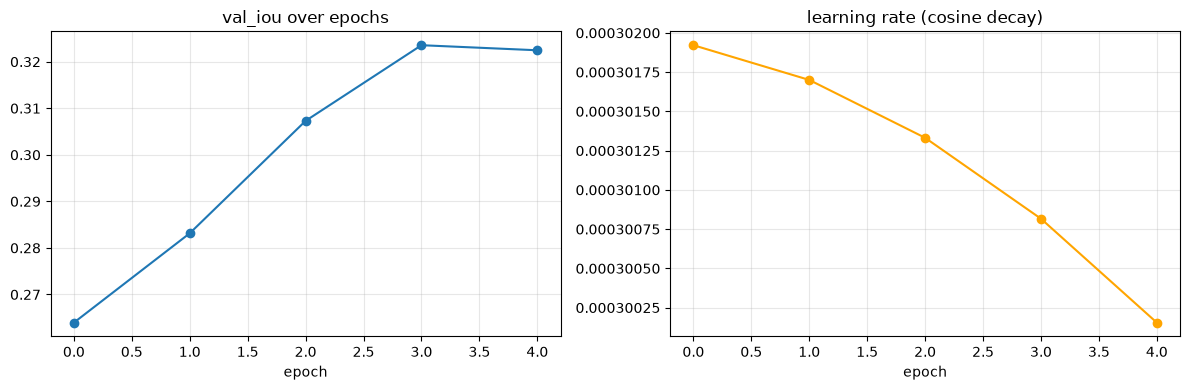


Epochs logged so far: 5   Best val_iou: 0.3235 at epoch 3


In [16]:
# ══════════════════════════════════════════════════════════════════════════
# Cell 7 — Check progress 
# ══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

alive = subprocess.run(["ps", "-p", str(FINAL_TRAIN_PID)], capture_output=True, text=True)
print("Process status:", "RUNNING" if str(FINAL_TRAIN_PID) in alive.stdout else "NOT RUNNING (finished or crashed — check the log)")

print("\n--- last 15 log lines ---")
if os.path.exists(TRAIN_LOG):
    with open(TRAIN_LOG) as f:
        lines = f.readlines()
    print("".join(lines[-15:]))

rows = []
if os.path.exists(METRICS_LOG):
    with open(METRICS_LOG) as f:
        for line in f:
            line = line.strip()
            if line: rows.append(json.loads(line))

if rows:
    epochs = [r["epoch"] for r in rows]
    ious   = [r["val_iou"] for r in rows]
    lrs    = [r["lr"] for r in rows]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, ious, marker="o")
    ax1.set_title("val_iou over epochs"); ax1.set_xlabel("epoch"); ax1.grid(alpha=0.3)
    ax2.plot(epochs, lrs, marker="o", color="orange")
    ax2.set_title("learning rate (cosine decay)"); ax2.set_xlabel("epoch"); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"\nEpochs logged so far: {len(rows)}   Best val_iou: {max(ious):.4f} at epoch {epochs[ious.index(max(ious))]}")
else:
    print("\nNo epoch metrics written yet — check back in a few minutes.")